In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, log_loss
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV


file_path = '/content/drive/MyDrive/Sreports_dse/dse_market_stress.csv'
df = pd.read_csv(file_path)


# Features (all columns except the target)
X = df[['daily_return', 'high_low_spread', 'intraday_volatility', 'volume_change_pct', 'price_gap',
        'rolling_5_day_volatility', 'rolling_10_day_momentum']]  # Same feature list as your notebook

# Convert features to float32 for efficiency
X = X.astype(np.float32)

# Target variable (market type)
y = df['market_type']

# Label encoding if necessary (market type classes: 0 = Normal, 1 = High Volatility, 2 = Crash)
le = LabelEncoder()
y = le.fit_transform(y)

# Convert target variable to float32 (if needed)
y = y.astype(np.float32)

In [ ]:
# Check for inf and NaN values in the dataset
print("Number of Infinite values in each column:\n", np.isinf(X).sum())
print("Number of NaN values in each column:\n", X.isna().sum())

Number of Infinite values in each column:
 daily_return                    0
high_low_spread                 0
intraday_volatility          1153
volume_change_pct           20614
price_gap                       0
rolling_5_day_volatility        0
rolling_10_day_momentum         0
dtype: int64
Number of NaN values in each column:
 daily_return                0
high_low_spread             0
intraday_volatility         0
volume_change_pct           0
price_gap                   0
rolling_5_day_volatility    0
rolling_10_day_momentum     0
dtype: int64


In [ ]:
# Replace inf with NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with NaN values (or you can use imputation methods)
X.dropna(inplace=True)
y = y[X.index]  # Ensure the target variable aligns with the dropped rows

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

extra_model = ExtraTreesClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 6, 10],
    "min_samples_split": [2, 5, 10]
}


cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

total_fits = 5 * 3  # n_iter=5, cv=3

print(f"\nRandomizedSearchCV settings:")
print(f"n_iter: 5")
print(f"cv folds: 3")
print(f"Total fits: {total_fits}\n")
print("Starting Randomized Search...\n")

random_search = RandomizedSearchCV(
    estimator=extra_model,
    param_distributions=param_grid,
    n_iter=5,
    scoring="accuracy",
    cv=cv3,
    verbose=3,
    random_state=42,
    n_jobs=-1,
    refit=True
)

random_search.fit(X_train, y_train)

print("\nRandomized Search Completed!")
print("Best Hyperparameters from RandomizedSearchCV: ", random_search.best_params_)

best_model = random_search.best_estimator_


RandomizedSearchCV settings:
n_iter: 5
cv folds: 3
Total fits: 15

Starting Randomized Search...

Fitting 3 folds for each of 5 candidates, totalling 15 fits

Randomized Search Completed!
Best Hyperparameters from RandomizedSearchCV:  {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 10}



Classification Report:
               precision    recall  f1-score   support

         0.0     0.9562    0.9395    0.9478    161997
         1.0     0.8799    0.8004    0.8383     51969
         2.0     0.0563    0.8948    0.1059       504

    accuracy                         0.9057    214470
   macro avg     0.6308    0.8783    0.6306    214470
weighted avg     0.9356    0.9057    0.9193    214470



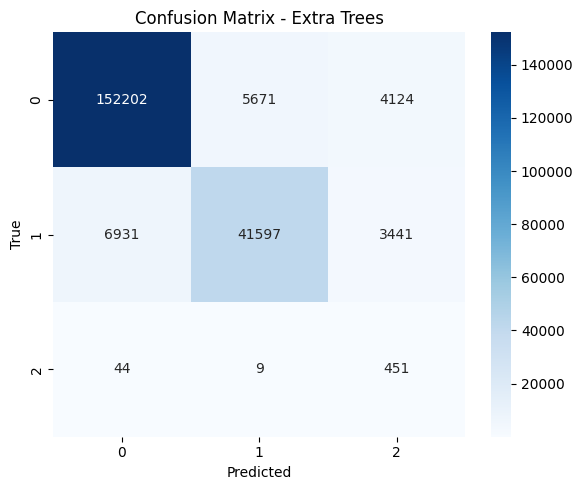

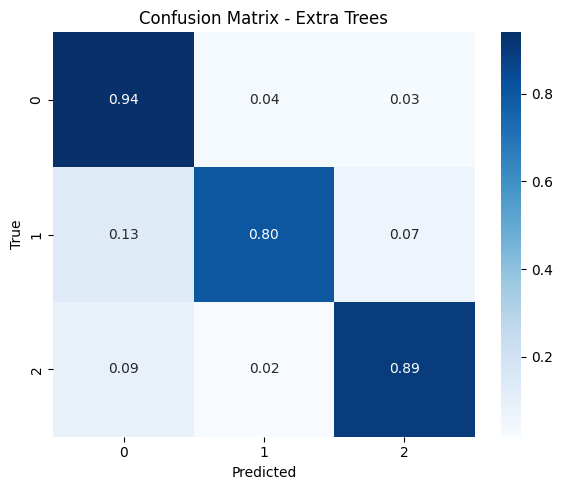

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predict on the test set
y_pred = best_model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Extra Trees')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Confusion Matrix
cm_normalized = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Extra Trees')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

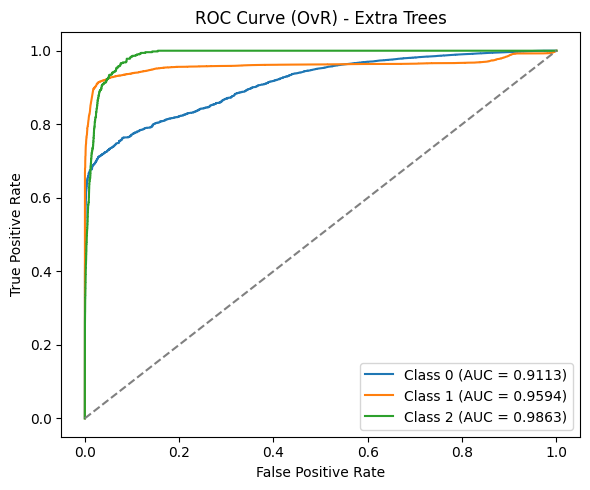

In [ ]:

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = np.unique(y_train).astype(int)
y_test_bin = label_binarize(y_test, classes=classes)

# Probabilities
y_proba = best_model.predict_proba(X_test)

fpr, tpr, roc_auc = {}, {}, {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6, 5))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve (OvR) - Extra Trees')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

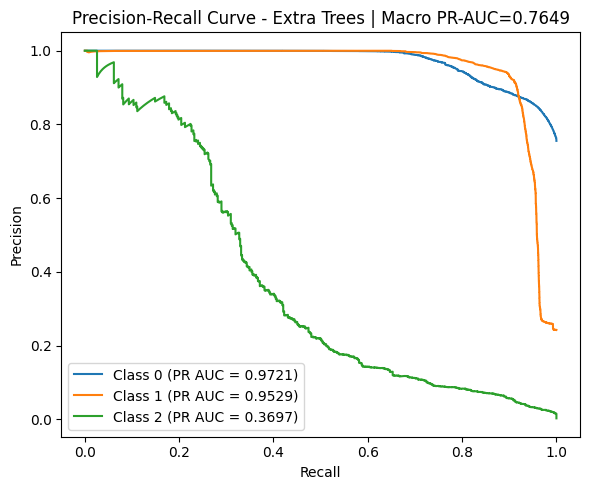

Per-class PR-AUC: {0: np.float64(0.9721256206483031), 1: np.float64(0.9529457929106546), 2: np.float64(0.369656119144178)}
Macro PR-AUC: 0.7649091775677119


In [ ]:

from sklearn.metrics import precision_recall_curve, auc

precision, recall, pr_auc = {}, {}, {}

plt.figure(figsize=(6, 5))

for i in range(len(classes)):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    pr_auc[i] = auc(recall[i], precision[i])
    plt.plot(recall[i], precision[i], label=f'Class {i} (PR AUC = {pr_auc[i]:.4f})')

macro_pr_auc = float(np.mean(list(pr_auc.values())))

plt.title(f'Precision-Recall Curve - Extra Trees | Macro PR-AUC={macro_pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

print("Per-class PR-AUC:", pr_auc)
print("Macro PR-AUC:", macro_pr_auc)

In [ ]:

from sklearn.model_selection import cross_validate

scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'neg_log_loss']

cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=cv3,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

print("\n===== Cross Validation Report (3-Fold) - Extra Trees =====\n")

for metric in scoring:
    scores = cv_results[f'test_{metric}']
    if metric == 'neg_log_loss':
        scores = -scores
        metric_name = "log_loss"
    else:
        metric_name = metric

    print(f"{metric_name}: {scores.mean():.4f} ± {scores.std():.4f}")


===== Cross Validation Report (3-Fold) - Extra Trees =====

accuracy: 0.9048 ± 0.0138
precision_macro: 0.6327 ± 0.0170
recall_macro: 0.8899 ± 0.0097
f1_macro: 0.6314 ± 0.0116
log_loss: 0.8528 ± 0.0453


In [ ]:

import os
import json
import joblib
from datetime import datetime
import numpy as np

# Folder name
SAVE_DIR = "extra_trees_dse_model"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1️⃣ Save Trained Model
joblib.dump(best_model, os.path.join(SAVE_DIR, "extra_trees_model.pkl"))

# 2️⃣ Save Label Encoder
joblib.dump(le, os.path.join(SAVE_DIR, "label_encoder.pkl"))

# 3️⃣ Save Feature Columns
feature_info = {"feature_columns": list(X.columns)}
with open(os.path.join(SAVE_DIR, "feature_columns.json"), "w") as f:
    json.dump(feature_info, f, indent=4)

# 4️⃣ Save Best Hyperparameters (convert numpy types -> python types)
best_params = {}
for k, v in random_search.best_params_.items():
    if isinstance(v, (np.integer, np.int64, np.int32)):
        v = int(v)
    elif isinstance(v, (np.floating, np.float64, np.float32)):
        v = float(v)
    best_params[str(k)] = v

with open(os.path.join(SAVE_DIR, "best_params.json"), "w") as f:
    json.dump(best_params, f, indent=4)

# 5️⃣ Save Cross Validation Results (Mean ± Std)
cv_summary = {}
for metric in scoring:
    scores = cv_results[f"test_{metric}"]

    if metric == "neg_log_loss":
        scores = -scores
        metric_name = "log_loss"
    else:
        metric_name = metric

    cv_summary[str(metric_name)] = {
        "mean": float(np.mean(scores)),
        "std": float(np.std(scores))
    }

with open(os.path.join(SAVE_DIR, "cv_results.json"), "w") as f:
    json.dump(cv_summary, f, indent=4)

# 6️⃣ Save Metadata (safe JSON types)
class_mapping = {}
for cls_name, cls_id in zip(le.classes_, le.transform(le.classes_)):
    class_mapping[str(cls_name)] = int(cls_id)

metadata = {
    "model_type": "ExtraTreesClassifier",
    "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset_shape": {
        "X_train": [int(X_train.shape[0]), int(X_train.shape[1])],
        "X_test":  [int(X_test.shape[0]),  int(X_test.shape[1])]
    },
    "class_mapping": class_mapping,
    "random_state": 42,
    "n_iter": 5,
    "cv_folds": 3
}

with open(os.path.join(SAVE_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)

print(f"\n✅ Extra Trees model package saved successfully in folder: {SAVE_DIR}")


✅ Extra Trees model package saved successfully in folder: extra_trees_dse_model
